170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 96ms/step - accuracy: 0.3740 - loss: 1.7298 - val_accuracy: 0.5512 - val_loss: 1.2665
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 86ms/step - accuracy: 0.5863 - loss: 1.1783 - val_accuracy: 0.6068 - val_loss: 1.1285
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 82ms/step - accuracy: 0.6455 - loss: 1.0224 - val_accuracy: 0.6140 - val_loss: 1.1231
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 85ms/step - accuracy: 0.6767 - loss: 0.9323 - val_accuracy: 0.6622 - val_loss: 0.9712
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 79s 81ms/step - accuracy: 0.7057 - loss: 0.8524 - val_accuracy: 0.6703 - val_loss: 0.9597
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 80ms/step - accuracy: 0.7309 - loss: 0.7826 - val_accuracy: 0.6907 - val_loss: 0.9140
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 81ms/step - accuracy: 0.7580 - loss: 0.7092 - val_accuracy: 0.6908 - val_loss: 0.9249
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━

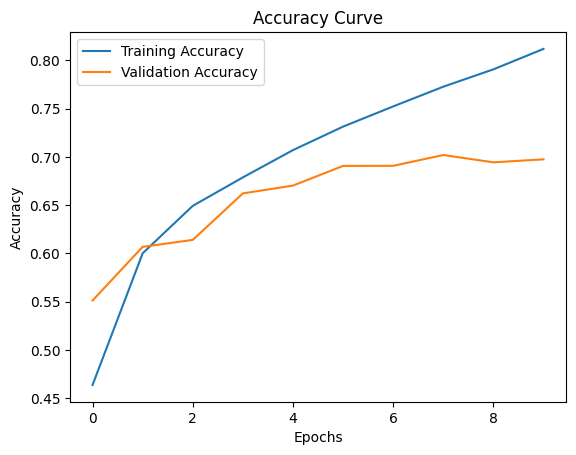

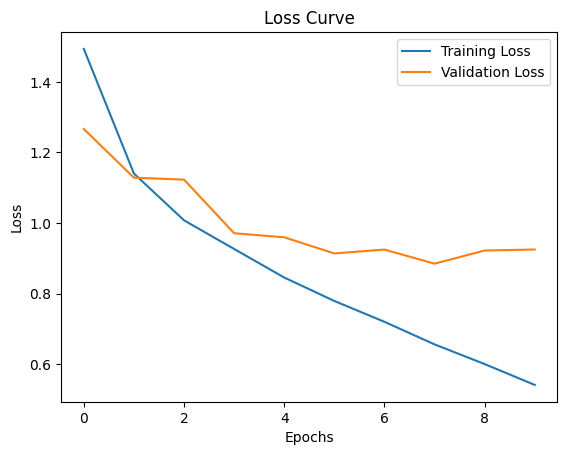

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6945 - loss: 0.9326
Test Accuracy: 0.694100022315979
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


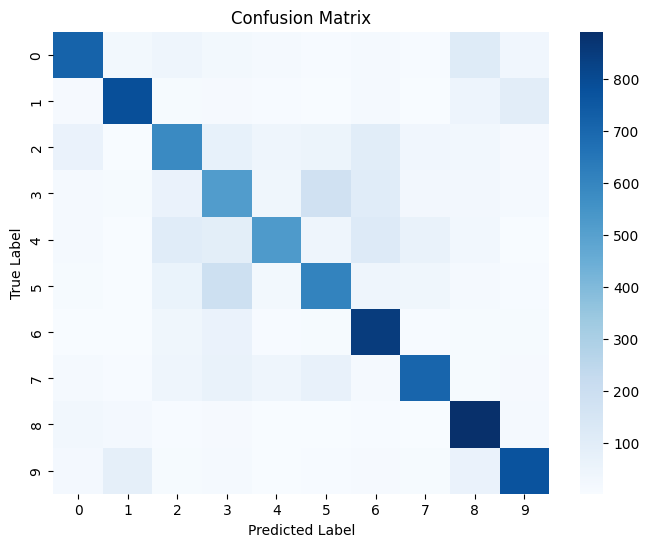

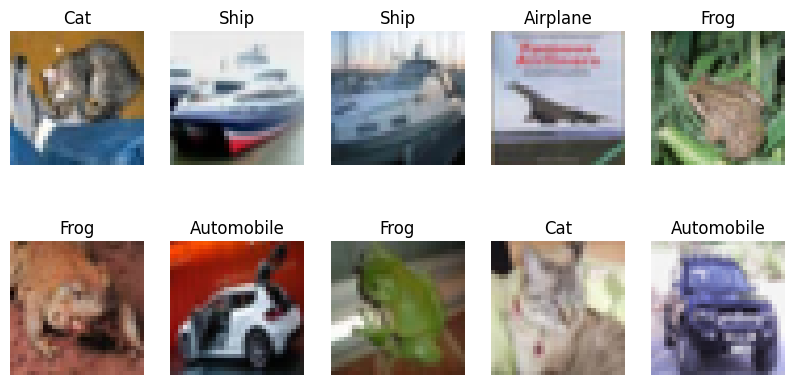

In [1]:
# =========================================
# MULTI-CLASS IMAGE CLASSIFICATION USING CNN
# =========================================

import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

# STEP 1: LOAD DATASET (CIFAR-10)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['Airplane','Automobile','Bird','Cat','Deer',
               'Dog','Frog','Horse','Ship','Truck']

# STEP 2: NORMALIZE DATA
x_train = x_train / 255.0
x_test = x_test / 255.0

# STEP 3: BUILD CNN MODEL
model = models.Sequential([
    layers.Input(shape=(32,32,3)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# STEP 4: COMPILE MODEL
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# STEP 5: TRAIN MODEL
history = model.fit(x_train, y_train,
                    epochs=10,
                    batch_size=64,
                    validation_split=0.2)

# STEP 6: PLOT ACCURACY AND LOSS
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.show()

# STEP 7: EVALUATE MODEL
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

# STEP 8: CONFUSION MATRIX
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# STEP 9: DISPLAY SAMPLE PREDICTIONS
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i])
    plt.title(class_names[y_pred_classes[i]])
    plt.axis('off')
plt.show()
